# TP1 PROCESAMIENTO DEL HABLA: webscrapping

**Crea una copia de este notebook en tu google colab**

**Renombra el notebook con el siguiente formato APELLIDO_NOMBRE_PH_TP1.ipynb**

**[Escriba aquí su nombre completo.]**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado usando los bloques de texto.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


### Importacion de librerias

A continuacion realizo la importacion de todas las librerias necesarias para la totalidad del documento

In [41]:
import requests
import re
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from bs4 import BeautifulSoup
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('stopwords')

/home/dynazenon/Documents/TogeToge/ProcesamientoDelHabla/.venv/lib/python3.12/site-packages/nltk/downloader.py:1076: UserWarning: NLTK will not authorize the non-private download directory '/home/dynazenon/nltk_data': it (or an ancestor) is world- or group-writable, so another local user could plant files there. Choose a private location such as ~/nltk_data.
  for msg in self.incr_download(info_or_id, download_dir, force):
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dynazenon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/dynazenon/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/dynazenon/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Webscraping. Pablo Imhoff

Desde www.ellitoral.com extraigo una entrevista a Pablo Imhoff, motociclista reconocido por haber logrado un viaje hasta Alaska - EEUU en una moto Honda Econo de 90cc

In [42]:
# URL original de la entrevista
url = "https://www.ellitoral.com/area-metropolitana/pablito-viajero-pablo-imhoff-motoviajero-alaska-regreso-entrevista-primera-santo-tome-santafe_0_dSglSKI7wp.html"

# Guardamos la entrevista en la variable soup
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

print(soup.prettify()) # Este print muestra el codigo html puro

<!DOCTYPE html>
<html lang="es">
 <head>
  <meta charset="utf-8" data-next-head=""/>
  <meta content="width=device-width" data-next-head="" name="viewport"/>
  <title data-next-head="">
   Cuando el mapa se vuelve carne: Pablo Imhoff y el viaje hasta el fin del norte
  </title>
  <meta content="pablito,viajero,pablo,imhoff,motoviajero,alaska,regreso,entrevista,primera,santo,tome,santafe" data-next-head="" property="keywords"/>
  <meta content="pablito,viajero,pablo,imhoff,motoviajero,alaska,regreso,entrevista,primera,santo,tome,santafe" data-next-head="" property="news_keywords"/>
  <meta content="3000" data-next-head="" http-equiv="refresh"/>
  <meta content="Nicolás Loyarte" data-next-head="" name="author"/>
  <meta content="Cuando el mapa se vuelve carne: Pablo Imhoff y el viaje hasta el fin del norte" data-next-head="" name="title"/>
  <meta content="El motoviajero regresó tras casi 6 años en la ruta y visitó la redacción para conversar sobre sus aventuras. “Ir lento en una moto ch

Aca solamente tomamos los parrafos que nos interesan de la entrevista y le quitamos todo lo relacionado al codigo html
Guardamos el texto en la variable "entrevista" en formato string

In [43]:
parrafos = soup.find_all("p") # Separo todos los tags "<p></p>" de toda la pagina
entrevista = ""

for parrafo in parrafos:
    texto = parrafo.get_text(strip=True)
    entrevista = entrevista + texto + " "
    print(texto)


El motoviajero regresó tras casi 6 años en la ruta y visitó la redacción para conversar sobre sus aventuras. “Ir lento en una moto chica me permitió empaparme de las culturas e interactuar con la gente de una manera que un vehículo grande no permite”, dijo en su visita a El Litoral. Cómo sigue su historia.
El cartel aparece al costado de la ruta como una revelación. Blanco, sobrio, definitivo: Welcome to Alaska. Pablo Imhoff frena la moto, apoya el casco sobre el asiento y enciende la cámara con las manos temblorosas. No hay música ni épica impostada. Solo una voz quebrada que dice lo que el cuerpo todavía no logra procesar:
“Creo que hemos llegado, gente… no lo puedo creer, llegamos… no lo puedo creer”.
Detrás de esa frase hay más de cinco años de ruta, más de 50 mil kilómetros recorridos, 15 países atravesados, fronteras cerradas, tormentas, frío extremo y una pandemia que congeló el mundo —y también su viaje— cuando recién comenzaba. Pero, sobre todo, hay una decisión: vivir despaci

Y asi ya se puede obserbar como nos quedo la entrevista completamente legible

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

Traemos las stopwords en español previamente importadas de nltk y le damos un update con la lista proporcionada por la profesora.
Tokenizamos la entrevista y mediante el for loop vamos guardando cada palabra que esté en la lista de stopwords

In [44]:
stopwords_es = set(stopwords.words('spanish'))
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

entrevista = entrevista.lower() # Pasamos todo el texto a minisculas

tokens = word_tokenize(entrevista, language='spanish')

stopwords_en_el_texto = [palabra for palabra in tokens if palabra in stopwords_es]
stopwords_en_el_texto = pd.Series(stopwords_en_el_texto)
stopwords_en_el_texto.drop_duplicates(inplace=True, ignore_index=True) # Borramos duplicados asi nos queda un ejemplar unico de cada stopword

print(stopwords_en_el_texto.to_string())

0             el
1           casi
2             en
3             la
4              y
5           para
6          sobre
7            sus
8            una
9             me
10            de
11           las
12             e
13           con
14           que
15            un
16            no
17            su
18             a
19          cómo
20            al
21          como
22           hay
23            ni
24          solo
25            lo
26         hemos
27           esa
28           más
29       también
30        cuando
31          pero
32          todo
33           era
34            yo
35          este
36         mismo
37          poco
38           los
39           uno
40           fue
41         desde
42         tiene
43       después
44           por
45            sí
46            se
47        siente
48         donde
49          cada
50             o
51           del
52           sin
53          nada
54           ese
55          esto
56            es
57           mío
58        porq

### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

A continuacion eliminamos stop-words y caracteres extraños del texto y las guardamos en la lista "entrevista_sin_stopwords"

In [45]:
entrevista = re.sub(r'[^\w\s]', ' ', entrevista)
tokens = word_tokenize(entrevista, language='spanish')

entrevista_sin_stopwords = [palabra for palabra in tokens if palabra not in stopwords_es]

print(entrevista_sin_stopwords)

['motoviajero', 'regresó', 'tras', '6', 'años', 'ruta', 'visitó', 'redacción', 'conversar', 'aventuras', 'ir', 'lento', 'moto', 'chica', 'permitió', 'empaparme', 'culturas', 'interactuar', 'gente', 'manera', 'vehículo', 'grande', 'permite', 'dijo', 'visita', 'litoral', 'sigue', 'historia', 'cartel', 'aparece', 'costado', 'ruta', 'revelación', 'blanco', 'sobrio', 'definitivo', 'welcome', 'to', 'alaska', 'pablo', 'imhoff', 'frena', 'moto', 'apoya', 'casco', 'asiento', 'enciende', 'cámara', 'manos', 'temblorosas', 'música', 'épica', 'impostada', 'voz', 'quebrada', 'dice', 'cuerpo', 'todavía', 'logra', 'procesar', 'creo', 'llegado', 'gente', 'puedo', 'creer', 'llegamos', 'puedo', 'creer', 'detrás', 'frase', 'cinco', 'años', 'ruta', '50', 'mil', 'kilómetros', 'recorridos', '15', 'países', 'atravesados', 'fronteras', 'cerradas', 'tormentas', 'frío', 'extremo', 'pandemia', 'congeló', 'mundo', 'viaje', 'recién', 'comenzaba', 'decisión', 'vivir', 'despacio', 'continente', 'acostumbrado', 'corre

Para armar la wordcloud necesitamos pasarle un formato string, asi la pasamos a formato string y podemos armar el wordcloud

In [46]:
entrevista_sin_stopwords_string = ""
for palabra in entrevista_sin_stopwords:
    entrevista_sin_stopwords_string += palabra + " "
    
wordcloud = WordCloud(width=1600, height=900, background_color="white", colormap="winter").generate(entrevista_sin_stopwords_string) # Aca cambiar width y heigth segun el tamaño de pantalla

Con matplot generamos el wordcloud

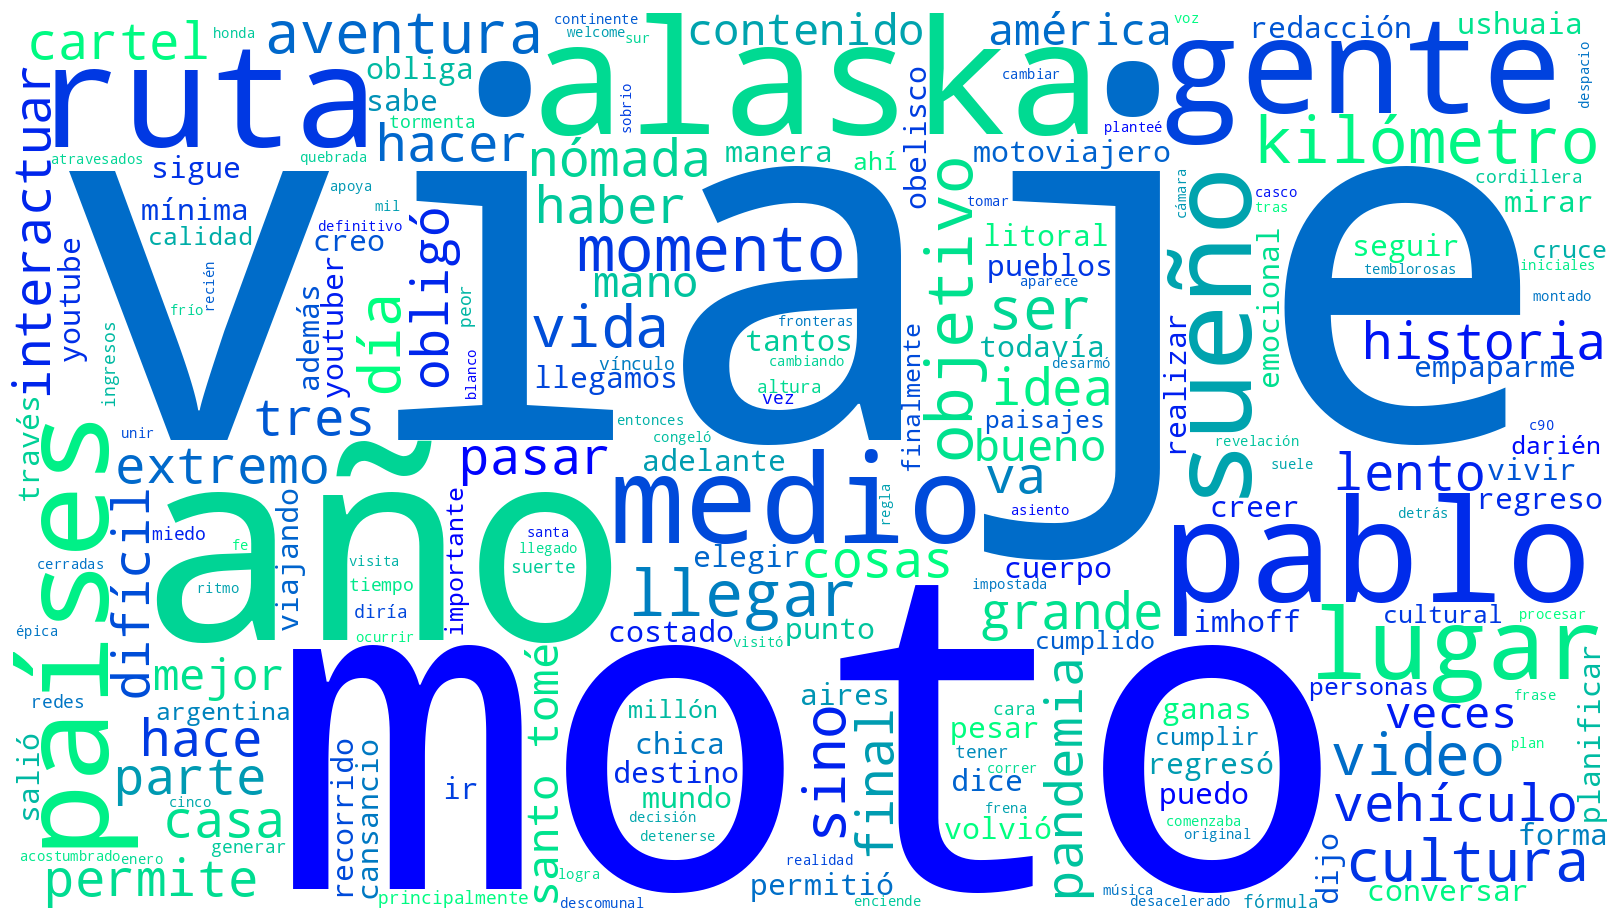

In [47]:
plt.figure(figsize=(16, 9), facecolor=None) # Aca el figsize tiene que ir de la mano con segun el width y heigth parametrizados en wordcloud
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

- Viaje
- Moto
- Alaska
- Año
- Ruta

Son las palabras que mas resaltan en el wordcloud

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


Eliminando caracteres innecesarios y dejando todo en minusculas, parrafo por parrafo los vamos guardando en un array

In [48]:
entrevista = []

for parrafo in parrafos:
    texto = parrafo.get_text(strip=False).lower()

    # Eliminar signos de puntuación
    texto = re.sub(r'[^\w\s]', '', texto)

    # Eliminar stopwords
    palabras = texto.split()
    palabras = [palabra for palabra in palabras if palabra not in stopwords_es]

    # Volver a unir las palabras
    texto = " ".join(palabras)

    entrevista.append(texto)

entrevista = np.array(entrevista)

print(entrevista)

['motoviajero regresó tras 6 años ruta visitó redacción conversar aventuras ir lento moto chica permitió empaparme culturas interactuar gente manera vehículo grande permite dijo visita litoral sigue historia'
 'cartel aparece costado ruta revelación blanco sobrio definitivo welcome to alaska pablo imhoff frena moto apoya casco asiento enciende cámara manos temblorosas música épica impostada voz quebrada dice cuerpo todavía logra procesar'
 'creo llegado gente puedo creer llegamos puedo creer'
 'detrás frase cinco años ruta 50 mil kilómetros recorridos 15 países atravesados fronteras cerradas tormentas frío extremo pandemia congeló mundo viaje recién comenzaba decisión vivir despacio continente acostumbrado correr'
 'pablo salió santo tomé santa fe enero 2020 montado honda c90 moto mínima sueño descomunal idea unir ushuaia alaska plan original tres años medio realidad suele ocurrir ruta desarmó'
 'viaje planteé hacer tres años medio viaje obligó tomar ritmo desacelerado entonces tres añ

Con CountVectorizer vectorizamos la entrevista y armamos la matriz documento-vocabulario

In [49]:
vectorizador = CountVectorizer()

matriz_documento_vocabulario = vectorizador.fit_transform(entrevista)

df_matriz = pd.DataFrame(
    matriz_documento_vocabulario.toarray(),
    columns=vectorizador.get_feature_names_out(),
    index=[f"Párrafo {i+1}" for i in range(len(entrevista))]
)

print(df_matriz.to_string())

            15  2014  2020  50  5000  56000  90  aborígenes  abra  acampando  acampar  acay  acercarse  acostumbrado  acto  acá  adaptarlo  adaptarte  adelante  además  afuera  agarró  ahí  aires  alaska  alcanzar  altura  alucinante  amarras  amigos  américa  andes  anteriores  antinatural  anunció  aparece  aparecen  apenas  apoya  aprendí  aprovechó  arepas  argentina  argentino  armar  arreglarla  asfalto  asiento  atravesados  atrás  avanzar  aventura  aventuras  aventurera  aventurero  ayudó  año  años  bajas  balance  bancarte  base  bautizó  baño  bienvenido  blanco  bueno  buenos  burocrática  c90  caigo  calidad  cama  cambiando  cambiar  cambien  cambio  camino  campeón  cansancio  cara  característico  carga  caribe  cartel  casa  casco  casualidad  cc  cerradas  cerré  certeza  chica  cierre  cilindradas  cinco  circunstancias  ciudad  clave  colectivo  comenzaba  comenzó  comidas  comparable  compartiendo  compartimos  complementado  completa  comunidad  conforman  congel

In [50]:
print(df_matriz.sum().sort_values(ascending=False).to_string())

viaje              12
alaska             10
años               10
moto               10
ruta                8
pablo               8
gente               7
países              6
medio               6
llegar              5
lugar               5
sueño               5
objetivo            4
kilómetros          4
ser                 4
vida                4
sino                4
mejor               3
15                  3
cartel              3
idea                3
interactuar         3
permite             3
obligó              3
parte               3
pasar               3
nómada              3
momentos            3
pandemia            3
motoviajero         3
lento               3
tomé                3
santo               3
tres                3
aventura            3
vehículo            3
veces               3
ushuaia             3
final               3
contenido           3
día                 3
culturas            3
hace                3
hacer               3
haber               3
casa      


#### 2.3.2 Determina la longitud de tu vocabulario.

In [51]:
print(f"Logitud del Vocabulario: {vectorizador.vocabulary_.__len__()}")

Logitud del Vocabulario: 591


La longitud del vocabulario es la cantidad de terminos unicos que hay en la entrevista.


#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [52]:
vocabulario = vectorizador.vocabulary_

tfidf = TfidfVectorizer(vocabulary=vocabulario)

matriz_tfidf = tfidf.fit_transform(entrevista)

df_tfidf = pd.DataFrame(
    matriz_tfidf.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=[f"Párrafo {i+1}" for i in range(len(entrevista))]
)

print(df_tfidf.to_string())

                  15      2014      2020        50      5000     56000        90  aborígenes      abra  acampando   acampar      acay  acercarse  acostumbrado      acto       acá  adaptarlo  adaptarte  adelante    además    afuera    agarró       ahí     aires    alaska  alcanzar    altura  alucinante   amarras    amigos   américa     andes  anteriores  antinatural   anunció   aparece  aparecen    apenas     apoya   aprendí  aprovechó    arepas  argentina  argentino    armar  arreglarla   asfalto   asiento  atravesados    atrás   avanzar  aventura  aventuras  aventurera  aventurero    ayudó       año      años     bajas   balance  bancarte      base   bautizó      baño  bienvenido    blanco     bueno    buenos  burocrática       c90     caigo   calidad      cama  cambiando   cambiar   cambien    cambio    camino   campeón  cansancio      cara  característico     carga    caribe    cartel      casa     casco  casualidad        cc  cerradas     cerré   certeza     chica    cierre  cilind

Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.

Podemos ver el tamaño de la matriz:

In [53]:
matriz_tfidf.shape

(46, 591)

Luego de haber limpiado caracteres ortograficos y quitado las stopwords nos quedan 46 parrafos y 591 palabras, 
brindandonos una gran cantidad de documentos y un vocabulario extenso.

# Conclusiones

Tarea muy interesante. Importante el uso e incorporacion de las variadas bibliotecas de Python, algunas que ya conocia
como Pandas, Numpy, sklearn y Matplotlib, y nuevas bibliotecas como nltk y BeautifulSoup.
Personalmente va tomando forma lo que me imaginaba al anotarme a esta carrera, el tomar algun tipo de informacion 
en "lenguaje humano" y poder "traducir" esa informacion al lenguaje numerico que comprenden las computadoras y las IA.

Fui realizando este proyecto utilizando el material y el repositorio facilitado por la docente en el aula virtual y
utilize IA para ir refactorizando y corrigiendo el codigo.
